## 1. Libraries and Setup
In this cell, we import all the necessary Python libraries:
- **`numpy`**: For vectorized linear algebra, matrix multiplications, and mathematical operations.
- **`matplotlib.pyplot` & `seaborn`**: For plotting our dataset distribution and visualizing the final non-linear decision boundary.
- **`pandas`**: For converting our raw arrays into a tabular data format.
- **`sklearn.datasets.make_moons`**: To generate a synthetic non-linear 2D binary classification dataset.
- **`sklearn.model_selection.train_test_split`**: To split the dataset into train and test sets to avoid overfitting.
- **`sklearn.preprocessing.StandardScaler`**: To standardize our dataset to mean=0 and variance=1.

In [420]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Generating the 'Moons' Dataset
We generate 1000 data points configured with a standard deviation noise level of `0.2`. This generates two interleaving half-circles of data, making it a classic benchmark dataset for testing non-linear classifiers.

In [421]:
X, y = make_moons(n_samples = 1000,
                  noise = 0.2,
                  random_state = 42)


## 3. Creating a Pandas DataFrame
Here we load the generated moon coordinates (`x1` and `x2`) alongside their class targets (labeled as either class `0` or class `1`) into a structured pandas DataFrame. This makes handling and plotting the data more robust.

In [422]:
df = pd.DataFrame(dict(x1=X[:,0], x2=X[:,1], label=y))

## 4. Visualizing the Dataset
We use `seaborn.scatterplot` to display our data distribution. We map `x1` on the horizontal axis, `x2` on the vertical axis, and assign distinct colors using the binary target `label` column. Notice the interlocking non-linear structure.

<Axes: xlabel='x1', ylabel='x2'>

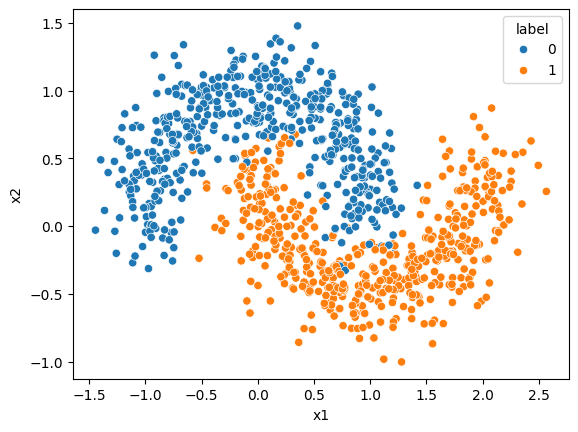

In [423]:
sns.scatterplot(data=df, x='x1', y='x2', hue='label')

## 5. Splitting Into Training & Testing Subsets
To properly evaluate our neural network, we partition the dataset into a **Training set (80%)** which the model will learn from, and a **Testing set (20%)** which remains unseen during training to evaluate the model's performance.

In [424]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size = 0.2,
                                                    random_state = 42)

## 6. Feature Normalization
Standardizing features helps stabilize training. We scale both the training and testing input data by subtracting the mean of the training data and dividing by its standard deviation:
$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

In [425]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test =  scaler.transform(X_test)

## 7. Dimension Verification
Before feeding vectors into a custom-built network, it's critical to verify the shapes of our arrays to avoid matrix multiplication mismatches:
- `X_train` should have shape `(800, 2)`.
- `y_train` should have shape `(800,)`.

In [426]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (800, 2)
y_train: (800,)
X_test: (200, 2)
y_test: (200,)


## 8. Weight & Bias Initialization (He Initialization)
For a three-layer neural network with the configuration: **$2 \rightarrow 16 \rightarrow 8 \rightarrow 1$**:
- **Layer 1 ($W_1, b_1$)**: Weights shape `(2, 16)`, Biases shape `(1, 16)`.
- **Layer 2 ($W_2, b_2$)**: Weights shape `(16, 8)`, Biases shape `(1, 8)`.
- **Layer 3 ($W_3, b_3$)**: Weights shape `(8, 1)`, Biases shape `(1, 1)`.

We utilize **He Initialization** to scale the weights by $\sqrt{\frac{2}{n^{[l-1]}}}$ to keep the variance of the layer outputs consistent and prevent vanishing/exploding gradients under ReLU activations.

In [427]:
W1 = np.random.randn(2, 16) * np.sqrt(2 / 2)
b1 = np.zeros((1, 16))

W2 = np.random.randn(16, 8) * np.sqrt(2 / 16)
b2 = np.zeros((1, 8))

W3 = np.random.randn(8, 1) * np.sqrt(2 / 8)
b3 = np.zeros((1, 1))

## 9. Learning Rate Parameter
We configure a static gradient descent learning rate parameter: `learning_rate = 0.01`. This controls the step size taken along the gradient direction in each optimization step.

In [428]:
learning_rate = 0.01

## 10. Packaging Parameters
We group all our weights ($W_1, W_2, W_3$) and biases ($b1, b2, b3$) into a parameter dictionary `params` to allow them to be passed cleanly across functions.

In [429]:
params = {
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2,
    "W3": W3,
    "b3": b3
}

## 11. Activation Functions
We define our mathematical activations:
1. **Sigmoid**: Compresses outputs into values between `0` and `1` to produce binary class probabilities:
   $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
2. **ReLU (Rectified Linear Unit)**: Element-wise non-linear activation that thresholds negative inputs to zero:
   $$\text{ReLU}(x) = \max(0, x)$$

In [430]:
def sigmoid(z):
  return (1/(1+ np.exp(-z)))

def ReLU(x):
  return np.maximum(0, x)

## 12. Forward Propagation & Loss Definition
- **`forward`**: Computes predictions by passing inputs through the network layers:
  - $Z_1 = X W_1 + b_1 \implies A_1 = \text{ReLU}(Z_1)$
  - $Z_2 = A_1 W_2 + b_2 \implies A_2 = \text{ReLU}(Z_2)$
  - $Z_3 = A_2 W_3 + b_3 \implies A_3 = \sigma(Z_3)$
  
- **`binary_cross_entropy`**: Calculates how close our model predictions are to the true labels. We add a tiny epsilon value ($10^{-8}$) to prevent numerical instability issues like $\log(0)$:
  $$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\left[ y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)}) \right]$$

In [431]:
def forward(X, params):

    W1 = params["W1"]
    b1 = params["b1"]

    W2 = params["W2"]
    b2 = params["b2"]

    W3 = params["W3"]
    b3 = params["b3"]

    # Layer 1
    Z1 = X @ W1 + b1
    A1 = ReLU(Z1)

    # Layer 2
    Z2 = A1 @ W2 + b2
    A2 = ReLU(Z2)

    # Output layer
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3
    }

    return A3, cache


def binary_cross_entropy(y, y_pred):

    epsilon = 1e-8

    loss = -np.mean(
        y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon)
    )

    return loss

## 13. Backpropagation (Gradient Computation)
We compute gradients using the chain rule over all layers, moving from the output layer back to the input layer:
- Output Layer error: $dZ_3 = A_3 - Y$
- Hidden Layer 2 error: $dZ_2 = (dZ_3 W_3^T) \odot \mathbb{I}(Z_2 > 0)$
- Hidden Layer 1 error: $dZ_1 = (dZ_2 W_2^T) \odot \mathbb{I}(Z_1 > 0)$

We output gradients for each weight matrix ($dW_1, dW_2, dW_3$) and bias vector ($db_1, db_2, db_3$).

In [432]:
def backward(X, y, params, cache):

    m = X.shape[0]

   # layer 1

    W1 = params["W1"]
    W2 = params["W2"]
    W3 = params["W3"]



    Z1 = cache["Z1"]
    A1 = cache["A1"]

    Z2 = cache["Z2"]
    A2 = cache["A2"]

    A3 = cache["A3"]


    y = y.reshape(-1, 1)


    # dL/dZ3
    dZ3 = A3 - y

    # dL/dW3
    dW3 = (1 / m) * (A2.T @ dZ3)

    # dL/db3
    db3 = (1 / m) * np.sum(
        dZ3,
        axis=0,
        keepdims=True
    )

    # Layer 2

    # dL/dA2
    dA2 = dZ3 @ W3.T

    # dL/dZ2
    dZ2 = dA2 * (Z2 > 0)

    # dL/dW2
    dW2 = (1 / m) * (A1.T @ dZ2)

    # dL/db2
    db2 = (1 / m) * np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )

    #Layer 3

    # dL/dA1
    dA1 = dZ2 @ W2.T

    # dL/dZ1
    dZ1 = dA1 * (Z1 > 0)

    # dL/dW1
    dW1 = (1 / m) * (X.T @ dZ1)

    # dL/db1
    db1 = (1 / m) * np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )

    #result

    grads = {
        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2,

        "dW3": dW3,
        "db3": db3
    }

    return grads

## 14. Parameter Update Function
This function adjusts our model weights and biases in-place in the negative direction of our computed loss gradients, scaled by our learning rate:
$$\theta = \theta - \alpha \cdot d\theta$$

In [433]:
def update(grads):
  params["W1"] -= learning_rate * grads["dW1"]
  params["b1"] -= learning_rate * grads["db1"]

  params["W2"] -= learning_rate * grads["dW2"]
  params["b2"] -= learning_rate * grads["db2"]

  params["W3"] -= learning_rate * grads["dW3"]
  params["b3"] -= learning_rate * grads["db3"]



## 15. Initial Baseline Loss Evaluation
Before training begins, we run a single forward pass on our model using our freshly initialized He weights to compute our baseline starting loss. Since the model has not optimized yet, we expect a high loss (around `0.68`).

In [434]:
y_pred, cache = forward(X_train, params)

loss = binary_cross_entropy(
    y_train.reshape(-1, 1),
    y_pred
)

print("Loss:", loss)

Loss: 0.680941978138542


## 16. Optimization Training Loop
We optimize the network by looping over 10,000 training iterations (epochs). In each epoch:
1. Compute prediction probabilities ($A_3$) with a forward pass.
2. Compute the training loss.
3. Compute loss gradients via backpropagation.
4. Update the weights and biases using our update rule.

In [435]:
for epoch in range(10000):

  y_pred, cache = forward(X_train, params)

  loss = binary_cross_entropy(y_train.reshape(-1, 1), y_pred)

  gradients = backward (X_train,y_train, params, cache)

  update(gradients)

print(loss)


0.07490477156957942


## 17. Testing Set Evaluation
We evaluate our final trained parameters on the unseen test set to measure the model's accuracy and verify that it has successfully generalized to new data.

In [ ]:
# Evaluate on Test Set
y_test_pred, _ = forward(X_test, params)
test_loss = binary_cross_entropy(y_test.reshape(-1, 1), y_test_pred)

# Calculate Test Accuracy (threshold at 0.5)
test_preds_binary = (y_test_pred >= 0.5).astype(int)
test_accuracy = np.mean(test_preds_binary == y_test.reshape(-1, 1))

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0533
Test Accuracy: 98.00%


## 18. Decision Boundary Visualization
To demonstrate that our 3-layer neural network has learned a complex, non-linear classifier, we build a coordinate grid, compute predictions across the space, and plot the contours. This shows the complex non-linear boundary wrapping perfectly around both moons.

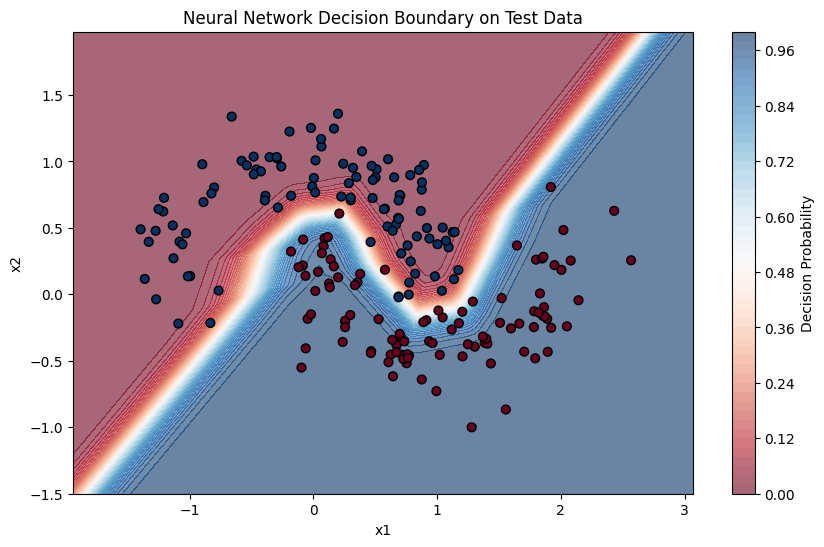

In [437]:
# Plot Decision Boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Scale grid points matching train preprocessing
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points_scaled = scaler.transform(grid_points)

# Forward pass on grid points
grid_preds, _ = forward(grid_points_scaled, params)
grid_preds = grid_preds.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, grid_preds, levels=50, cmap='RdBu', alpha=0.6)
plt.colorbar(label='Decision Probability')
plt.scatter(X_test[:, 0] * scaler.scale_[0] + scaler.mean_[0],
            X_test[:, 1] * scaler.scale_[1] + scaler.mean_[1],
            c=y_test, cmap='RdBu_r', edgecolors='k', s=40)
plt.title("Neural Network Decision Boundary on Test Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()